# Calculate temperature deficit in surface mixed layer

In [54]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:42625")
client

<Client: 'tcp://127.0.0.1:42625' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

In [7]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

### Calculate potential density

In [8]:
# Convert depth (m) to pressure (dbar)
p = gsw.p_from_z(HH_grid.Z, 70)  # Depth is negative

# Convert Practical Salinity (SP) to Absolute Salinity (SA)
SA = gsw.SA_from_SP(SALT_zarr_day.SALT, p, SALT_zarr_day.XC, SALT_zarr_day.YC)  # Assume longitude = 0 if unknown

# Convert Potential Temperature to Conservative Temperature
CT = gsw.conversions.CT_from_pt(SA, THETA_zarr_day.THETA)

# Calculate potential density anomaly referenced to 0 dbar (1000 is subtracted)
sigma0 = gsw.sigma0(SA, CT)

In [9]:
sigma0.name = 'potential_density'
sigma0.attrs['long_name'] = 'potential_density'

### Calculate temperature deficit in ML

In [20]:
def calculate_mld(sigma0_array, density_threshold=0.03):
    """
    Calculate the Mixed Layer Depth (MLD) for a time series of a profile at k=90.
    
    Parameters:
    sigma0_array (xarray.DataArray): Potential density dataset with dimensions (time, k).
    density_threshold (float): Density increase threshold to define the MLD (default = 0.03 kg/m^3).
    
    Returns:
    xarray.DataArray: MLD time series corresponding to depth where density exceeds threshold.
    """
    
    # Select surface density
    rho_Z0 = sigma0_array.isel(k=0)
    
    # Compute threshold density
    threshold = (rho_Z0 + density_threshold)
    
    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_array - threshold)
    
    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    
    # Extract the corresponding depth value for MLD
    MLD_array = sigma0_array.isel(k=threshold_idx.compute()).Z
    
    return MLD_array, threshold_idx

In [42]:
def calculate_temperature_deficit(temp, salinity, volume, threshold_idx):
    """
    Calculate the temperature deficit for the mixed layer using the gsw package for freezing point calculation.
    
    Parameters:
    temp (xr.DataArray): Temperature profile of the mixed layer (degC)
    salinity (xr.DataArray): Salinity profile of the mixed layer (PSU)
    volume (xr.DataArray): Volume of each grid cell in the mixed layer (m3)
    threshold_idx (xr.DataArray): 1D array containing the maximum depth index for the MLD of each profile along the time series.
    
    Returns:
    float: Temperature deficit (degC)
    """

    # Given array of indices
    indices = threshold_idx.compute()

    # Create mask for surface mixed layer
    mask = temp.k <= indices

    # Apply mask
    temp_mld = temp.where(mask) # for MLD
    salt_mld = salinity.where(mask)
    vol_mld = volume.where(mask)
    
    # Calculate volume-weighted average temperature and salinity
    temp_avg_mld = (temp_mld * vol_mld).sum(dim='k') / np.sum(vol_mld)
    salt_avg_mld = (salt_mld * vol_mld).sum(dim='k') / np.sum(vol_mld)

    # Calculate freezing temperature using gsw with volume-weighted average salinity
    temp_freezing = gsw.t_freezing(salt_avg_mld, 0, 0)  # 0 pressure, 0 saturation
    
    # Temperature deficit
    temp_deficit = temp_avg_mld - temp_freezing
    
    return temp_deficit

In [13]:
volume = HH_grid.drF * HH_grid.rAc * HH_grid.hFacC

i_west=540
j_west=250

i_plume=565
j_plume=180

i_east=660
j_east=120

In [47]:
salt_pt_west = SALT_zarr_day.SALT.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_west = THETA_zarr_day.THETA.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_west = sigma0.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01')) + 1000 # convert to pot density from potential density anomaly
vol_pt_west = volume.isel(i=i_west,j=j_west).compute()
sic_west = SI_zarr_day.SIarea.isel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))*100

In [48]:
salt_pt_plume = SALT_zarr_day.SALT.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_plume = THETA_zarr_day.THETA.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_plume = sigma0.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01')) + 1000
vol_pt_plume = volume.isel(i=i_plume,j=j_plume).compute()
sic_plume = SI_zarr_day.SIarea.isel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))*100

In [49]:
salt_pt_east = SALT_zarr_day.SALT.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_east = THETA_zarr_day.THETA.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_east = sigma0.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01')) + 1000
vol_pt_east = volume.isel(i=i_east,j=j_east).compute()
sic_east = SI_zarr_day.SIarea.isel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))*100

In [50]:
# calculate mld and the index of the mld along k coord
mld_pt_west, threshold_idx_west = calculate_mld(density_pt_west, density_threshold=0.03)
mld_pt_plume, threshold_idx_plume = calculate_mld(density_pt_plume, density_threshold=0.03)
mld_pt_east, threshold_idx_east = calculate_mld(density_pt_east, density_threshold=0.03)

In [51]:
# calculate T deficit
temp_deficit_mld_west = calculate_temperature_deficit(theta_pt_west, salt_pt_west, vol_pt_west, threshold_idx_west).compute()
temp_deficit_mld_plume = calculate_temperature_deficit(theta_pt_plume, salt_pt_plume, vol_pt_plume, threshold_idx_plume).compute()
temp_deficit_mld_east = calculate_temperature_deficit(theta_pt_east, salt_pt_east, vol_pt_east, threshold_idx_east).compute()

In [25]:
# sanity check vals
print(theta_pt_east.isel(time=0).values[0:5])
print(salt_pt_east.isel(time=0).values[0:5])
print(density_pt_east.isel(time=0).values[0:5])
print(vol_pt_east.values[0:5])
print(threshold_idx_east.values[0:5])

[-1.2968384  -1.22747934 -1.21073425 -0.09678689  0.79995602]
[24.56088448 24.62095833 24.66266823 25.53451538 26.80315018]
[1019.70872509 1019.75714653 1019.79084071 1020.4798005  1021.47228557]
[12455181.58091584 14198907.00224406 16191736.05519059 18558220.5555646
 21173808.68755693]
[1 2 1 3 3]


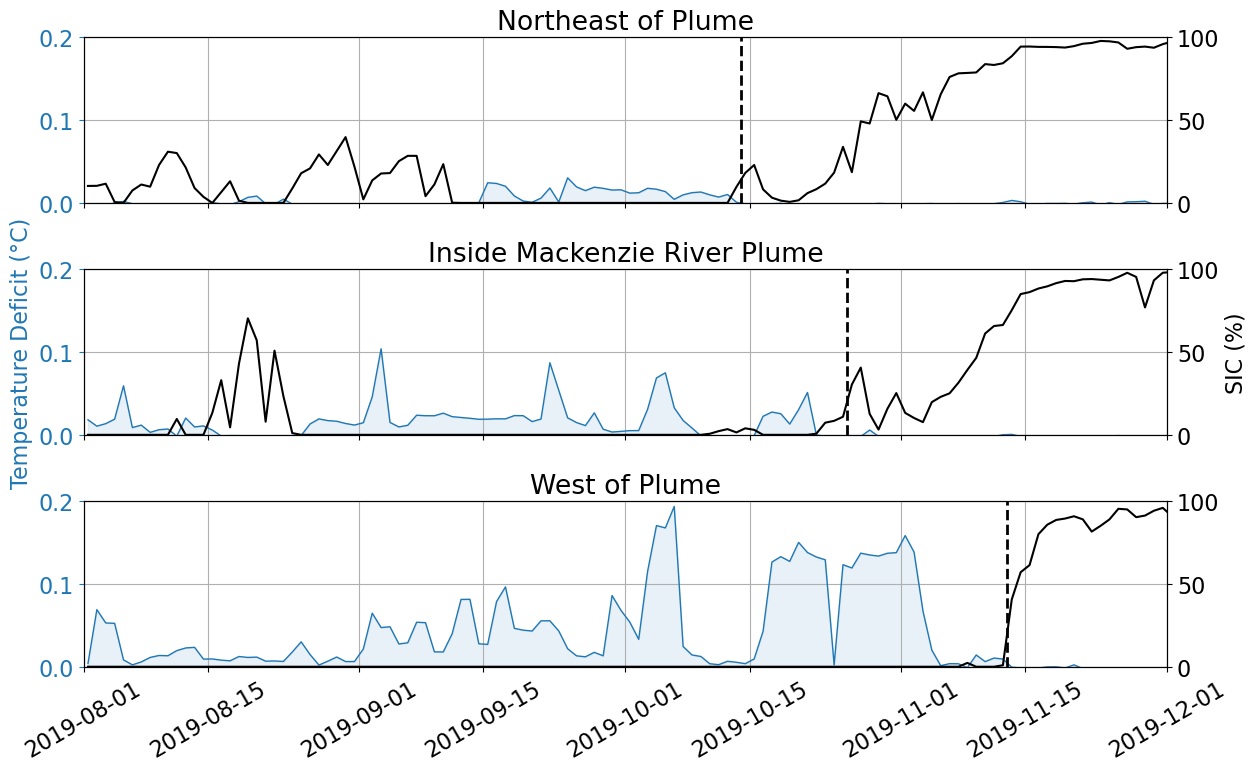

In [63]:
plt.rcParams['font.size'] = 16

# Create a figure with 3 rows, shared x-axis
fig, axes = plt.subplots(nrows=3, figsize=(13, 8), sharex=True)

# Data and titles for each subplot
temp_deficit_data = [
    (temp_deficit_mld_east, sic_east, "Northeast of Plume"),
    (temp_deficit_mld_plume, sic_plume, "Inside Mackenzie River Plume"),
    (temp_deficit_mld_west, sic_west, "West of Plume")
]

# Plot each dataset in a loop
for i, (ax, (temp_deficit, sic, title)) in enumerate(zip(axes, temp_deficit_data)):
    # Plot temperature deficit on primary y-axis (left)
    temp_deficit.plot(ax=ax, color='tab:blue', linewidth=1, label="Temperature Deficit")

    # Shade area below the blue line
    ax.fill_between(temp_deficit.time, temp_deficit, color='tab:blue', alpha=0.1)

    # Set primary y-axis label color
    ax.yaxis.label.set_color('tab:blue')
    ax.tick_params(axis='y', colors='tab:blue')

    # Create secondary y-axis for sea ice concentration
    ax2 = ax.twinx()
    sic.plot(ax=ax2, color='k', linewidth=1.5, linestyle='solid', label="SIC")
    ax2.set_ylim(0, 100)

    ax.set_title("")
    ax2.set_title("")
    ax.set_xlabel("")
    ax2.set_xlabel("")

    # Only set secondary y-axis label for the middle plot
    if i == 1:
        ax2.set_ylabel("SIC (%)", color='k')
    else:
        ax2.set_ylabel("")

    ax.set_ylim(0, 0.2)

    # Formatting
    ax.set_title(title)
    ax.grid()

# Set shared y-label for primary axis
axes[1].set_ylabel("Temperature Deficit (°C)", color='tab:blue')

# Add day when sea ice concentration > 15%
axes[0].axvline(x=np.datetime64('2019-10-14'), linestyle='dashed', linewidth=2, color='k')
axes[1].axvline(x=np.datetime64('2019-10-26'), linestyle='dashed', linewidth=2, color='k')
axes[2].axvline(x=np.datetime64('2019-11-13'), linestyle='dashed', linewidth=2, color='k')

# Set x-axis limits based on dataset min/max
min_time = np.datetime64('2019-08-01')
max_time = np.datetime64('2019-12-01')
axes[-1].set_xlim(min_time, max_time)

# Improve x-axis date formatting on the last axis
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()